In [1]:
import os
import sys
from pathlib import Path
import anndata as ad
import scanpy as sc
import numpy as np
import warnings
import math
import torch
from GEASO.utils.utils import intersect, feature_extract
from GEASO.alignment.coarse_alignment import coarse_alignment
from GEASO.alignment.elastic_registration import ElasticRegistration
import seaborn as sns
import pyvista as pv
from matplotlib import pyplot as plt

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.rcdefaults()

In [2]:
data_folder = "E:/st_data/3D_rec/OpenST/split_data"
results_folder = "./results/GEASEO_OpenST/"
Path(results_folder).mkdir(parents=True, exist_ok=True)

In [3]:
import re
def list_and_sort_files_by_number(directory_path, suffix):
    def extract_number(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else float('inf')
    try:
        files = [f for f in os.listdir(directory_path) if f.endswith(suffix)]
        sorted_files = sorted(files, key=extract_number)
        return sorted_files
    except FileNotFoundError:
        return f"The directory {directory_path} does not exist."
    except NotADirectoryError:
        return f"The path {directory_path} is not a directory."
    except PermissionError:
        return f"Permission denied to access {directory_path}."

directory_path = data_folder
sorted_files = list_and_sort_files_by_number(directory_path, '.h5ad')

In [4]:
from tqdm import tqdm
 
def load_slices(sorted_files, data_folder, step=1):
    files_to_read = sorted_files[::step]
    slices = []
    for f in tqdm(files_to_read, desc=f"step={step}"):
        path = os.path.join(data_folder, f)
        adata = ad.read_h5ad(path)
        slices.append(adata)
    return slices

slices = load_slices(sorted_files, data_folder, step=1)

step=1: 100%|██████████| 19/19 [00:04<00:00,  3.88it/s]


### Generate rotation matrices

In [5]:
rotations = []
for i in range(len(sorted_files)):
    theta = np.random.rand() * 2 * np.pi
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    rotations.append(rotation_matrix)

In [6]:
spatial_key = "spatial"
anno_key = "annotation"
rotate_key = "spatial_rot"
key_added = "aligned_spatial_rigid"

for i in range(len(slices)):
    slices[i].obsm[rotate_key] = slices[i].obsm[spatial_key][:,:2].copy()
    if i > 0:
        mean = np.mean(slices[i].obsm[rotate_key], axis=0)
        slices[i].obsm[rotate_key] = slices[i].obsm[rotate_key] - mean
        slices[i].obsm[rotate_key] = slices[i].obsm[rotate_key] @ rotations[i].T + mean

C:\Users\wangyu\AppData\Local\Temp\ipykernel_44228\3267744006.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial_rot']` of view, initializing view as actual.
  slices[i].obsm[rotate_key] = slices[i].obsm[spatial_key][:,:2].copy()


## Perform GEASO alignment iteratively

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for i in tqdm(range(len(slices)-1), position=0, leave=True):
    section_ids = ['target', 'source']
    slice1, slice2 = slices[i].copy(), slices[i+1].copy()
    slice1.obs['batch'] = section_ids[0]
    slice2.obs['batch'] = section_ids[1]
    
    target_slice = slice1.copy()
    source_slice = slice2.copy()

    # extract features of slices
    common_genes = intersect(source_slice.var_names, target_slice.var_names)
    source_slice = source_slice[:, common_genes]
    target_slice = target_slice[:, common_genes]
    adata_list = [source_slice, target_slice]
    emb_dict, loss_log, model = feature_extract(adata_list, if_plot=False)
    target_slice.obsm['latent'] = emb_dict[section_ids[0]].cpu().numpy()
    source_slice.obsm['latent'] = emb_dict[section_ids[1]].cpu().numpy()
    torch.cuda.empty_cache()

    R, t, scale, P, spatial_scales, spatial_means, guided_source, guided_target, coarse_source, coarse_target = coarse_alignment(source=source_slice, target=target_slice, top_K=10, dis_metric='kl', use_latent=True, scale_c=False)
    target_slice.obsm['spatial_coarse'] = coarse_target.copy()
    source_slice.obsm['spatial_coarse'] = coarse_source.copy()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    register_model = ElasticRegistration(
        init_P=P,
        guided_source=guided_source,
        guided_target=guided_target,
        source_slice=source_slice,
        target_slice=target_slice,
        normalize_scales=spatial_scales,
        normalize_means=spatial_means,
        spatial_key='spatial_coarse',
        dissimilarity='euc',
        device=device,
        max_iter=200,
    )
    torch.cuda.empty_cache()
    
    # correct the coordinates of source slice (i.e., the i+1 slice)
    slices[i + 1].obsm[rotate_key] = source_slice.obsm[key_added].copy()

  0%|          | 0/18 [00:00<?, ?it/s]C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Training on cuda, please wait...


Epoch: 199, Loss: -428.140 step time=0.271s: 100%|██████████| 200/200 [00:56<00:00,  3.54it/s]


Local structure kernel constructed with shape: torch.Size([20000, 100])


Slice Alignment:   0%|          | 0/200 [00:00<?, ?it/s]D:\st_projects\GEASO\GEASO\alignment\elastic_registration.py:199: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  decay_val = torch.tensor(decay_val, device=self.SVI_decay.device, dtype=self.SVI_decay.dtype)
  6%|▌         | 1/18 [01:24<24:00, 84.72s/it]C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


...

Slice Alignment:   0%|          | 0/200 [00:00<?, ?it/s]D:\st_projects\GEASO\GEASO\alignment\elastic_registration.py:199: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  decay_val = torch.tensor(decay_val, device=self.SVI_decay.device, dtype=self.SVI_decay.dtype)
 94%|█████████▍| 17/18 [23:42<01:23, 83.43s/it]C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\ProgramData\anaconda3\envs\gpudeepl\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Training on cuda, please wait...


Epoch: 199, Loss: -437.609 step time=0.289s: 100%|██████████| 200/200 [00:56<00:00,  3.56it/s]


Local structure kernel constructed with shape: torch.Size([20000, 100])


Slice Alignment:   0%|          | 0/200 [00:00<?, ?it/s]D:\st_projects\GEASO\GEASO\alignment\elastic_registration.py:199: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  decay_val = torch.tensor(decay_val, device=self.SVI_decay.device, dtype=self.SVI_decay.dtype)
100%|██████████| 18/18 [25:06<00:00, 83.67s/it]


17


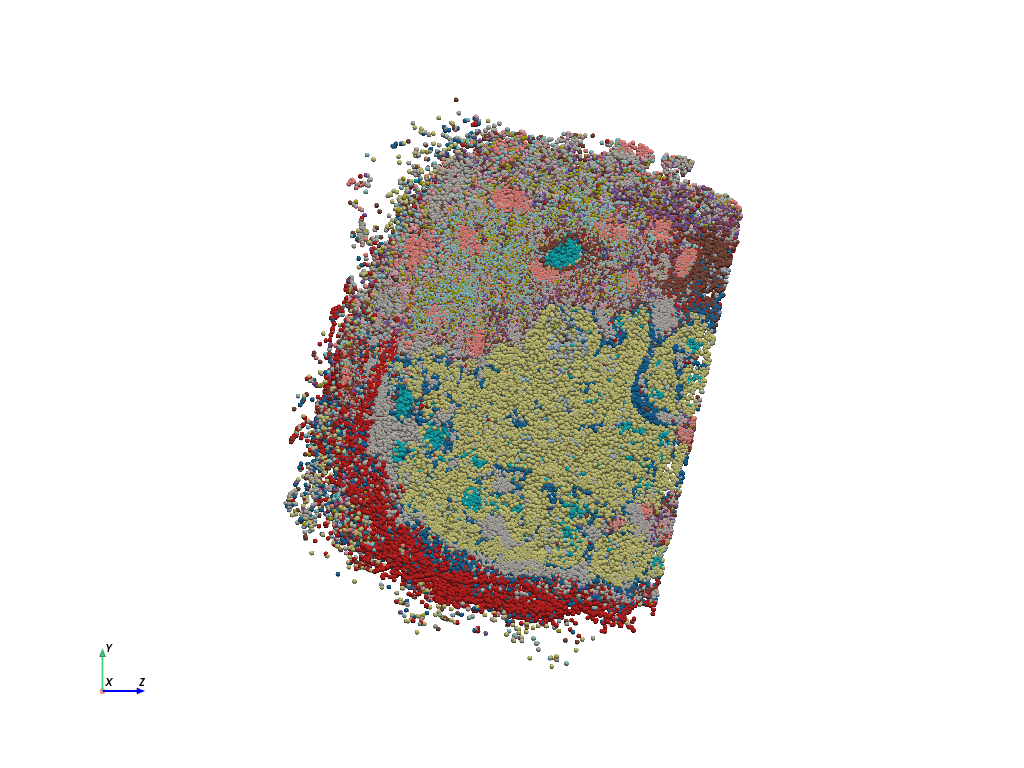

In [8]:
import numpy as np

adata_all = sc.concat(slices, label='batch')
adata_all.obsm['correct_spatial'] = np.concatenate((adata_all.obsm['spatial_3d_aligned'][:, 2][:, None] * 3, adata_all.obsm[rotate_key][:, : 2]), axis=1)
coords = adata_all.obsm['correct_spatial'].copy()
cell_types = adata_all.obs['annotation']
print(len(cell_types.unique()))
labels = cell_types.cat.codes
categories = list(cell_types.cat.categories)
cmap = plt.get_cmap('tab20', len(categories))
categories = list(cell_types.cat.categories)

cloud = pv.PolyData(coords)
# cloud.point_data['cell_type_code'] = labels

plotter = pv.Plotter()
plotter.add_mesh(
    cloud,
    scalars=labels,
    render_points_as_spheres=True,
    point_size=5,
    show_scalar_bar=False,
    cmap=cmap,
    
)

plotter.add_axes()
plotter.show(title='3D Spatial Transcriptomics: Cell Types', cpos='zy', jupyter_backend='static')

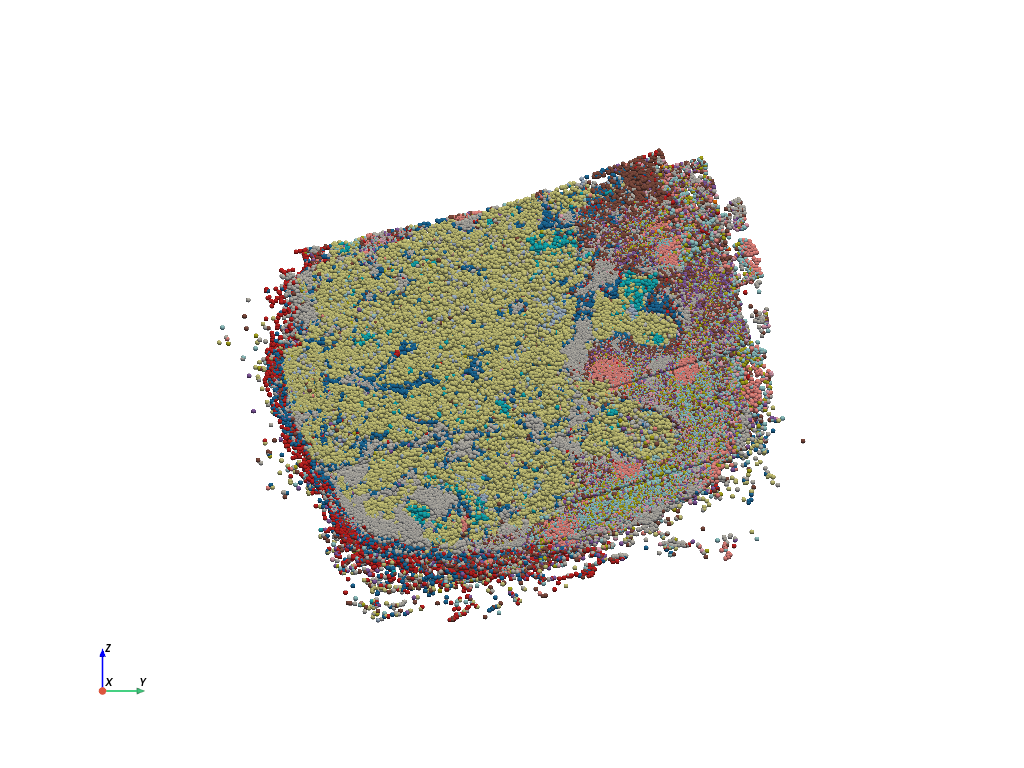

In [22]:
plotter.show(title='3D Spatial Transcriptomics: Cell Types', cpos='zx', jupyter_backend='static')